# Tree-Type Neural Network of small MLPs on a jointly-trained CNN trunk (Cats-vs-Dogs & CIFAR-10)  —  v2
**Idea.** (Jayadeva's tree-type NN) A node produces a score `h`; its hard decision splits samples into C1(TN) C2(TP) C3(FN) C4(FP). Child **A** learns C3-vs-rest (ignores C2), child **B** learns C4-vs-rest (ignores C1); parent score `z = h + α·A − β·B` (α,β ≥ 0), children recurse.

**What is new here (all trained from scratch, no pretrained weights):**
* **Trunk** = small CNN trained end-to-end with a softmax head; the head *is* the root node of the tree(s). Multi-scale pooled trunk features (`shallow`,`mid`,`deep`) are the *views* given to child nodes.
* **Every child node = small hourglass MLP** on those features. Multiclass = one tree per class (one-vs-rest), decoded by arg-max.
* A held-out **validation split** selects every hyper-parameter (never the test set).

**What changed in v2**
1. **The tree matters more.** The CNN trunk is now deliberately *under-fit* (early-stopped; epochs are chosen automatically so that its **train accuracy lies in 90–95 %**, `BAND`). The tree then has real work to do and the climb to ≥ 99.9 % train accuracy ("overfit to 100 %") is done *by the tree itself*. A converged CNN is kept as a reference row.
2. **Double descent is better supported:** dense widths 6–16, 3 seeds, longer training on cats-vs-dogs, a lower (standard-error based) tolerance, and a per-seed consistency count in the verdict.
3. **Size minimisation is defensible:** accuracy-vs-parameters plots, smaller roots (narrower trunks), tree-node pruning (post-hoc, validated), and the *smallest model within one standard error of the best validation accuracy* (not merely the smallest one that hits the target).
4. **Receptive-field write-up:** a placeholder cell is reserved after the plots for your own observations.

Every code cell starts with a banner `▶ STEP n/12`. Needs a GPU (Kaggle: Accelerator → GPU T4); falls back to a much smaller CPU mode automatically.

## STEP 1 — Configuration & imports

In [2]:
import os, sys, glob, json, math, heapq, itertools, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, cv2
import torch, torch.nn as nn, torch.nn.functional as F
warnings.filterwarnings('ignore'); T0 = time.time(); NSTEPS = 12
def STEP(n, msg):
    e = int(time.time()-T0); print('\n' + '='*96 + f'\n▶ STEP {n}/{NSTEPS}: {msg}   [elapsed {e//60:02d}:{e%60:02d}]\n' + '='*96)
STEP(1, 'configuration, imports, device')

DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
MODE = 'SMOKE' if os.environ.get('SMOKE') else ('GPU' if DEV == 'cuda' else 'CPU')
SEED = 0; TARGET_TRAIN_ACC = 0.999      # the TREE keeps growing until DECODED TRAIN accuracy >= this ("interpolation")
BAND = (0.90, 0.95)                     # the CNN trunk is deliberately UNDER-FIT: epochs/recipe are picked so its own train accuracy lies in this band -> the tree has real work to do
INTERP = 0.999; NOISE = 0.20            # INTERP: train-acc threshold marking interpolation in double-descent; NOISE: label noise for DD only
DD_TOL_MIN = 0.005                      # double-descent heuristic: smallest rise/drop (absolute test error) that can count (was 0.01; also now scaled by the standard error, not 2x the s.d.)
VAL_SE_K = 1.0                          # size minimisation: "good" = validation accuracy within VAL_SE_K binomial standard errors of the best interpolating model (one-standard-error rule)
MAX_DEPTH = 8; NODE_LR = 1e-2; NODE_EP = 60; NODE_BS = 512
P = dict(
 GPU  =dict(CD_RES=64, CD_N=(8000,2000),  C10_N=(15000,10000), TRUNK_EP_GRID=[5,7,9,12,16], REF_EP=30, TRUNK_GRID=[(48,.05,5e-4),(64,.05,5e-4),(64,.10,1e-3)],
            DD_W=[1,2,4,6,7,8,9,10,11,12,14,16,24,32,48], DD_SEEDS=[0,1,2], DD_N=dict(cd=3000,c10=4000), DD_EP=dict(cd=120,c10=60), DD_NODES=dict(cd=10,c10=30), DD_TE=2000,
            SIZE_W=[8,12,16,24,32,48], MAX_TOTAL=dict(cd=150,c10=500), MAX_NODES=dict(cd=100,c10=60), CHECK=dict(cd=2,c10=10)),
 CPU  =dict(CD_RES=32, CD_N=(2000,600),   C10_N=(3000,1000),   TRUNK_EP_GRID=[3,5,8], REF_EP=12, TRUNK_GRID=[(16,.05,5e-4),(32,.05,5e-4)],
            DD_W=[1,2,4,6,8,10,12,16], DD_SEEDS=[0,1,2], DD_N=dict(cd=1000,c10=1500), DD_EP=dict(cd=40,c10=30), DD_NODES=dict(cd=6,c10=15), DD_TE=600,
            SIZE_W=[4,8,16], MAX_TOTAL=dict(cd=60,c10=150), MAX_NODES=dict(cd=40,c10=25), CHECK=dict(cd=2,c10=5)),
 SMOKE=dict(CD_RES=32, CD_N=(300,100),    C10_N=(400,150),     TRUNK_EP_GRID=[2,4], REF_EP=4, TRUNK_GRID=[(8,.05,5e-4)],
            DD_W=[2,4,6,8,10], DD_SEEDS=[0,1,2], DD_N=dict(cd=200,c10=200), DD_EP=dict(cd=3,c10=3), DD_NODES=dict(cd=3,c10=5), DD_TE=100,
            SIZE_W=[4,8], MAX_TOTAL=dict(cd=15,c10=30), MAX_NODES=dict(cd=15,c10=8), CHECK=dict(cd=1,c10=2)))[MODE]
globals().update(P)
# tree hyper-parameter grid: (feature strategy, node MLP depth, node base width)
TREE_GRID = [('shared',2,16), ('varied',2,16), ('varied',3,32), ('varied',1,8), ('varied',1,4)]
OUT = '/kaggle/working' if os.path.isdir('/kaggle/working') else ('/tmp/out' if MODE=='SMOKE' else './outputs'); os.makedirs(OUT, exist_ok=True)
RES_FILE = f'{OUT}/results_{MODE}.json'; RES = json.load(open(RES_FILE)) if os.path.exists(RES_FILE) else {}
def cached(key, fn):                                   # resumable JSON cache for the long sweeps
    if key not in RES:
        RES[key] = fn(); json.dump(RES, open(RES_FILE,'w'), default=lambda o: o.item() if hasattr(o,'item') else str(o))
    return RES[key]
def seed_all(s): np.random.seed(s); torch.manual_seed(s)
seed_all(SEED)
print(f'MODE={MODE} device={DEV} | tree target train acc {TARGET_TRAIN_ACC} | CNN trunk train-acc band {BAND} | outputs -> {OUT}')
if MODE == 'CPU': print('WARNING: no GPU found -> reduced CPU mode (smaller data/epochs). Enable a GPU accelerator for the full experiment.')


▶ STEP 1/12: configuration, imports, device   [elapsed 00:00]
MODE=GPU device=cuda | tree target train acc 0.999 | CNN trunk train-acc band (0.9, 0.95) | outputs -> /kaggle/working


## STEP 2 — Datasets (train / validation / test; cached to disk)

In [3]:
STEP(2, 'loading Cats-vs-Dogs and CIFAR-10 (train / val / test)')
from PIL import Image
C10_NAMES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
HF_TOKEN = os.environ.get('HF_TOKEN', '').strip()
if not HF_TOKEN:
    try:
        from kaggle_secrets import UserSecretsClient; HF_TOKEN = UserSecretsClient().get_secret('HF_TOKEN').strip()
    except Exception: pass
def _fit(pil, r): return np.asarray(pil.convert('RGB').resize((r,r), Image.BILINEAR), dtype=np.uint8)
def load_cd(n, seed):
    rng = np.random.RandomState(seed); files = []
    for pat in ('*.jpg','*.jpeg','*.png'): files += glob.glob('/kaggle/input/**/'+pat, recursive=True)
    lab = lambda f: 0 if 'cat' in (os.path.basename(f)+os.path.dirname(f)).lower() else (1 if 'dog' in (os.path.basename(f)+os.path.dirname(f)).lower() else -1)
    files = [f for f in files if lab(f) >= 0]
    X, y = [], []
    if len(files) >= n:
        print('Cats-vs-Dogs: local Kaggle files'); 
        for i in rng.permutation(len(files)):
            try: X.append(_fit(Image.open(files[i]), CD_RES)); y.append(lab(files[i]))
            except Exception: continue
            if len(X) == n: break
    else:
        import datasets                                  # direct HF Hub parquet route (fast; cached after first run)
        print('Cats-vs-Dogs: HF Hub microsoft/cats_vs_dogs (first run downloads ~720MB)')
        kw = dict(split='train', download_mode='reuse_dataset_if_exists'); kw.update(token=HF_TOKEN) if HF_TOKEN else None
        ds = datasets.load_dataset('microsoft/cats_vs_dogs', **kw).shuffle(seed=int(seed)); ds = ds.select(range(min(n+300, len(ds))))
        for i in range(len(ds)):
            try: ex = ds[i]; X.append(_fit(ex['image'], CD_RES)); y.append(int(ex['labels'] if 'labels' in ex else ex['label']))
            except Exception: continue
            if len(X) == n: break
    if len(X) < n: raise RuntimeError(f'only {len(X)} valid images, need {n}')
    return np.stack(X), np.asarray(y, np.int64)
def load_c10():
    try:
        import torchvision
        tr = torchvision.datasets.CIFAR10(f'{OUT}/data', True, download=True); te = torchvision.datasets.CIFAR10(f'{OUT}/data', False, download=True)
        return tr.data, np.asarray(tr.targets), te.data, np.asarray(te.targets)
    except Exception as e:
        import datasets; print('torchvision failed -> HF uoft-cs/cifar10', e); d = datasets.load_dataset('uoft-cs/cifar10')
        g = lambda s: (np.stack([np.asarray(i) for i in d[s]['img']]), np.asarray(d[s]['label'])); (a,b),(c,e2) = g('train'), g('test'); return a,b,c,e2
def synthetic(n, res, nc, seed):                         # SMOKE mode only: class-dependent colour/texture blobs
    r = np.random.RandomState(seed); y = r.randint(0, nc, n); base = r.rand(nc, 3)*180
    X = np.clip(base[y][:,None,None,:] + r.randn(n,res,res,3)*40 + (np.arange(res)[None,:,None,None]*y[:,None,None,None]*2), 0, 255).astype(np.uint8); return X, y
def get_images(ds):
    ntr_all, nte = CD_N if ds == 'cd' else C10_N; res = CD_RES if ds == 'cd' else 32
    f = f'{OUT}/img_{MODE}_{ds}_{ntr_all}_{nte}_{res}_{SEED}.npz'
    if os.path.exists(f): z = np.load(f); print(f'{ds}: cached images'); return z['a'], z['b'], z['c'], z['d']
    if MODE == 'SMOKE': X, y = synthetic(ntr_all+nte, res, 2 if ds=='cd' else 10, 1); r = (X[:ntr_all], y[:ntr_all], X[ntr_all:], y[ntr_all:])
    elif ds == 'cd': X, y = load_cd(ntr_all+nte, SEED); r = (X[:ntr_all], y[:ntr_all], X[ntr_all:], y[ntr_all:])
    else:
        Xa, ya, Xb, yb = load_c10(); rng = np.random.RandomState(SEED); a = rng.permutation(len(Xa))[:ntr_all]; b = rng.permutation(len(Xb))[:nte]; r = (Xa[a], ya[a], Xb[b], yb[b])
    np.savez_compressed(f, a=r[0], b=r[1], c=r[2], d=r[3]); return r
NC = dict(cd=2, c10=10); NAMES = dict(cd=['cat','dog'], c10=C10_NAMES); IM = {}
t_ = lambda X: torch.from_numpy(np.ascontiguousarray(X)).permute(0,3,1,2).contiguous()      # uint8 NHWC -> NCHW
for ds in ['cd','c10']:
    Xa, ya, Xte, yte = get_images(ds); nv = int(.15*len(Xa)); ntr = len(Xa) - nv            # 85% train / 15% validation of the training pool
    IM[ds] = dict(Xtr=t_(Xa[:ntr]), ytr=ya[:ntr], Xva=t_(Xa[ntr:]), yva=ya[ntr:], Xte=t_(Xte), yte=yte)
    print(f'{ds}: train {ntr} | val {nv} | test {len(Xte)} | image {Xa.shape[1]}x{Xa.shape[2]} | class balance (train) {np.bincount(ya[:ntr]).tolist()}')


▶ STEP 2/12: loading Cats-vs-Dogs and CIFAR-10 (train / val / test)   [elapsed 00:00]
Cats-vs-Dogs: HF Hub microsoft/cats_vs_dogs (first run downloads ~720MB)


README.md:   0%|          | 0.00/8.16k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  330MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  391MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/23410 [00:00<?, ? examples/s]

cd: train 6800 | val 1200 | test 2000 | image 64x64 | class balance (train) [3443, 3357]


100%|██████████| 170M/170M [09:59<00:00, 284kB/s] 


c10: train 12750 | val 2250 | test 10000 | image 32x32 | class balance (train) [1304, 1278, 1286, 1290, 1260, 1279, 1213, 1280, 1259, 1301]


## STEP 3 — CNN trunk (trained jointly with its softmax head = tree root): definitions

In [4]:
STEP(3, 'defining CNN trunk, training routine, feature extraction, view builder')
def prep(x): return (x.to(DEV).float()/255. - .5)/.25
def augment(x):                                          # per-sample random flip + translation (GPU, reflect padding)
    n = x.shape[0]; th = torch.zeros(n,2,3, device=x.device); th[:,0,0] = (torch.rand(n, device=x.device) < .5).float()*2-1; th[:,1,1] = 1
    th[:,:,2] = (torch.rand(n,2, device=x.device)-.5)*.25
    return F.grid_sample(x, F.affine_grid(th, x.shape, align_corners=False), padding_mode='reflection', align_corners=False)
class Trunk(nn.Module):                                   # 3 stages (w,2w,4w channels); pooled features of every stage are exposed as views
    def __init__(s, w, nc, res):
        super().__init__(); s.w = w
        blk = lambda i,o,st=1: nn.Sequential(nn.Conv2d(i,o,3,st,1,bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True))
        s.s1 = nn.Sequential(blk(3,w,2 if res >= 64 else 1), blk(w,w), nn.MaxPool2d(2))
        s.s2 = nn.Sequential(blk(w,2*w), blk(2*w,2*w), nn.MaxPool2d(2)); s.s3 = nn.Sequential(blk(2*w,4*w), blk(4*w,4*w)); s.head = nn.Linear(4*w, nc)
    def feats(s, x): a = s.s1(x); b = s.s2(a); c = s.s3(b); return [a.mean((2,3)), b.mean((2,3)), c.mean((2,3))]
    def forward(s, x): return s.head(s.feats(x)[2])
def train_trunk(X, y, nc, w, ep, lr, wd, seed, aug=True, opt='sgd', bs=128):
    torch.manual_seed(seed); n = len(X); m = Trunk(w, nc, X.shape[-1]).to(DEV); Xg = X.to(DEV); yg = torch.as_tensor(y).long().to(DEV); spe = math.ceil(n/bs)
    if opt == 'sgd': o = torch.optim.SGD(m.parameters(), lr=lr, momentum=.9, weight_decay=wd, nesterov=True); sch = torch.optim.lr_scheduler.OneCycleLR(o, lr, total_steps=ep*spe, pct_start=.25)
    else: o = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd); sch = None
    sc = torch.amp.GradScaler(DEV, enabled=DEV=='cuda')
    for e in range(ep):
        m.train(); perm = torch.randperm(n, device=DEV)
        for i in range(0, n, bs):
            b = perm[i:i+bs]; x = prep(Xg[b]); x = augment(x) if aug else x
            with torch.autocast(DEV, enabled=DEV=='cuda'): loss = F.cross_entropy(m(x), yg[b])
            o.zero_grad(set_to_none=True); sc.scale(loss).backward(); sc.step(o); sc.update(); sch.step() if sch else None
    return m.eval()
@torch.no_grad()
def extract(m, X, bs=1000):
    L, Fs = [], []
    for i in range(0, len(X), bs):
        with torch.autocast(DEV, enabled=DEV=='cuda'): f = m.feats(prep(X[i:i+bs])); L.append(m.head(f[2]).float().cpu()); Fs.append(torch.cat(f,1).float().cpu())
    return torch.cat(L), torch.cat(Fs)
def root_scores(lg, nc):                                  # root-node score of every tree: binary log-odds (K=1) or one-vs-rest log-odds (K=nc)
    if nc == 2: return (lg[:,1]-lg[:,0])[:,None]
    return torch.stack([lg[:,k] - torch.logsumexp(torch.cat([lg[:,:k], lg[:,k+1:]],1),1) for k in range(nc)], 1)
def make_D(m, X3, y3, nc, names):                         # X3,y3 = (train,val,test); features are standardised with TRAIN statistics only
    Xall = torch.cat(X3); lg, Fe = extract(m, Xall); ntr, nva, nte = map(len, X3); mu = Fe[:ntr].mean(0); sd = Fe[:ntr].std(0)+1e-6; w = m.w
    return dict(ntr=ntr, nva=nva, nte=nte, ntot=len(Xall), ytr=y3[0], yva=y3[1], yte=y3[2], nc=nc, names=names, logits=lg, R=root_scores(lg,nc).numpy(), F=((Fe-mu)/sd).clamp(-6,6),
                mu=mu, sd=sd, sl=dict(shallow=slice(0,w), mid=slice(w,3*w), deep=slice(3*w,7*w)), trunk=m, tparams=sum(p.numel() for p in m.parameters()), V={})
def take(D, Fz, name):                                    # view = '+'-joined stages; 'all' = shallow+mid+deep
    parts = []
    for p in name.split('+'): parts += ['shallow','mid','deep'] if p == 'all' else [p]
    return torch.cat([Fz[:,D['sl'][p]] for p in dict.fromkeys(parts)], 1)
def view(D, name):
    if name not in D['V']: D['V'][name] = take(D, D['F'], name).contiguous()
    return D['V'][name]
def cnn_acc(D, ycls=None):                                # accuracy of the trunk's own softmax head (= root nodes only, no tree)
    P_ = D['logits'].argmax(1).numpy(); n, v = D['ntr'], D['nva']; yt = D['ytr'] if ycls is None else ycls
    return dict(tr=float((P_[:n]==yt).mean()), va=float((P_[n:n+v]==D['yva']).mean()) if v else float('nan'), te=float((P_[n+v:]==D['yte']).mean()))
print('trunk parameter counts: ', {w: sum(p.numel() for p in Trunk(w,10,32).parameters()) for w in [8,32,64]})


▶ STEP 3/12: defining CNN trunk, training routine, feature extraction, view builder   [elapsed 10:57]
trunk parameter counts:  {8: 18626, 32: 288746, 64: 1148874}


## STEP 4 — Under-fit CNN trunk (train accuracy 90–95 %) → features for the tree
Trunks are trained over a grid of `(width, lr, wd)` × `epochs`. **Stopping early is what keeps the CNN under-fit** (note: *less* augmentation would do the opposite — it makes a CNN fit the training set *better*). Selection rule, on the **validation** split: among trunks whose **train accuracy is inside `BAND`**, take the one with the best validation accuracy (if none falls in the band, the closest one is used and a warning is printed). A fully converged trunk is trained once as a *reference*.

In [5]:
STEP(4, 'training under-fit CNN trunks over (width, lr, wd) x epochs; keep the one whose TRAIN accuracy is inside BAND with the best VALIDATION accuracy')
DATA, TRUNK_ROWS, REFD, SEL = {}, [], {}, {}
def load_or_train(ds, w, lr, wd, ep):
    I = IM[ds]; fn = f'{OUT}/trunk_v2_{MODE}_{ds}_{w}_{lr}_{wd}_{ep}.pt'; t0 = time.time()
    if os.path.exists(fn): m = Trunk(w, NC[ds], I['Xtr'].shape[-1]).to(DEV); m.load_state_dict(torch.load(fn, map_location=DEV)); return m.eval(), 'cached'
    m = train_trunk(I['Xtr'], I['ytr'], NC[ds], w, ep, lr, wd, SEED); torch.save(m.state_dict(), fn); return m, f'trained in {time.time()-t0:.0f}s'
def build_D(ds, m): I = IM[ds]; return make_D(m, (I['Xtr'],I['Xva'],I['Xte']), (I['ytr'],I['yva'],I['yte']), NC[ds], NAMES[ds])
mid_band = sum(BAND)/2
for ds in ['cd','c10']:
    rows = []
    for (w, lr, wd) in TRUNK_GRID:
        for ep in TRUNK_EP_GRID:
            m, how = load_or_train(ds, w, lr, wd, ep); D = build_D(ds, m); a = cnn_acc(D); inb = bool(BAND[0] <= a['tr'] <= BAND[1])
            rows.append(dict(dataset=ds, width=w, lr=lr, wd=wd, epochs=ep, params=D['tparams'], train_acc=a['tr'], val_acc=a['va'], test_acc=a['te'], in_band=inb))
            print(f'  [{ds}] w={w} lr={lr} wd={wd} ep={ep:2d} ({how}): train {a["tr"]:.4f} val {a["va"]:.4f} (test {a["te"]:.4f}) {"<- in band" if inb else ""}'); del D
    R_ = pd.DataFrame(rows); TRUNK_ROWS += rows; ib = R_[R_.in_band]
    if len(ib): pk = ib.sort_values(['val_acc','params'], ascending=[False,True]).iloc[0]; why = f'train acc inside {BAND}; best validation accuracy among {len(ib)} in-band trunks'
    else: pk = R_.iloc[int((R_.train_acc-mid_band).abs().values.argmin())]; why = f'WARNING: no trunk inside {BAND}; took the one closest to {mid_band:.3f}'
    SEL[ds] = dict(w=int(pk.width), lr=float(pk.lr), wd=float(pk.wd), ep=int(pk.epochs)); s = SEL[ds]
    DATA[ds] = build_D(ds, load_or_train(ds, s['w'], s['lr'], s['wd'], s['ep'])[0])                        # SELECTED = under-fit trunk
    REFD[ds] = build_D(ds, load_or_train(ds, s['w'], s['lr'], s['wd'], REF_EP)[0]); a, r = cnn_acc(DATA[ds]), cnn_acc(REFD[ds])   # REFERENCE = same recipe, converged
    print(f'  -> [{ds}] selected under-fit trunk {s} ({why}): train {a["tr"]:.4f} val {a["va"]:.4f} test {a["te"]:.4f}')
    print(f'     reference converged trunk ({REF_EP} ep):                      train {r["tr"]:.4f} val {r["va"]:.4f} test {r["te"]:.4f}')
TRD = pd.DataFrame(TRUNK_ROWS); TRD.to_csv(f'{OUT}/trunk_grid.csv', index=False)


▶ STEP 4/12: training under-fit CNN trunks over (width, lr, wd) x epochs; keep the one whose TRAIN accuracy is inside BAND with the best VALIDATION accuracy   [elapsed 10:57]
  [cd] w=48 lr=0.05 wd=0.0005 ep= 5 (trained in 6s): train 0.8412 val 0.8208 (test 0.8240) 
  [cd] w=48 lr=0.05 wd=0.0005 ep= 7 (trained in 4s): train 0.8669 val 0.8508 (test 0.8505) 
  [cd] w=48 lr=0.05 wd=0.0005 ep= 9 (trained in 5s): train 0.8857 val 0.8617 (test 0.8655) 
  [cd] w=48 lr=0.05 wd=0.0005 ep=12 (trained in 7s): train 0.9103 val 0.8758 (test 0.8740) <- in band
  [cd] w=48 lr=0.05 wd=0.0005 ep=16 (trained in 10s): train 0.9326 val 0.8892 (test 0.8850) <- in band
  [cd] w=64 lr=0.05 wd=0.0005 ep= 5 (trained in 4s): train 0.8415 val 0.8292 (test 0.8235) 
  [cd] w=64 lr=0.05 wd=0.0005 ep= 7 (trained in 5s): train 0.8587 val 0.8425 (test 0.8465) 
  [cd] w=64 lr=0.05 wd=0.0005 ep= 9 (trained in 7s): train 0.8935 val 0.8700 (test 0.8600) 
  [cd] w=64 lr=0.05 wd=0.0005 ep=12 (trained in 9s): train 0.9122 v

## STEP 5 — Tree-Type NN with MLP nodes: algorithm

In [6]:
STEP(5, 'defining the tree-type network (nodes = MLPs, children A/B with don\'t-care sets, alpha/beta fitting, joint best-first growth)')
def get_layer_widths(L, base, peak=2):                    # hourglass widths for an L-hidden-layer node MLP
    if L <= 0: return []
    if L == 1: return [int(base)]
    k = L//2; span = max(k, L-1-k); return [max(1, int(round(base*(1+(peak-1)*(1-abs(i-k)/span))))) for i in range(L)]
def make_mlp(din, widths):
    layers, d = [], din
    for w in widths: layers += [nn.Linear(d,w), nn.ReLU()]; d = w
    return nn.Sequential(*layers, nn.Linear(d,1))         # widths=[] -> single linear neuron (paper's original node)
def const_node(din, val):
    m = nn.Linear(din,1); nn.init.zeros_(m.weight); nn.init.constant_(m.bias, val); m.is_const = True; return m
def train_node(X, t, widths, seed, max_ep, lr, bs, min_steps=300):
    din = X.shape[1]; torch.manual_seed(seed)
    if float(t.min()) == float(t.max()): return const_node(din, 3. if t[0] > .5 else -3.)       # pure set -> constant node
    m = make_mlp(din, widths); m.is_const = False; n = len(X); spe = math.ceil(n/bs); ep = min(400, max(max_ep, math.ceil(min_steps/spe)))   # tiny hard sets get >= min_steps updates
    opt = torch.optim.Adam(m.parameters(), lr=lr); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=ep*spe)
    lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(min(20., float((t<.5).sum())/max(1., float((t>.5).sum())))))   # correction sets are imbalanced
    for e in range(ep):
        perm = torch.randperm(n)
        for i in range(0, n, bs): b = perm[i:i+bs]; opt.zero_grad(); lossf(m(X[b]).squeeze(1), t[b]).backward(); opt.step(); sched.step()
        if e % 3 == 2 or e == ep-1:
            with torch.no_grad(): z = m(X).squeeze(1)
            if not torch.isfinite(z).all(): return const_node(din, 0.)
            if ((z > 0) == (t > .5)).all(): break          # node perfect on its own set
    return m
def fit_w(base, t, out, sign):                            # best alpha (A, sign=+1) / beta (B, sign=-1) >= 0 on the node's own training set; candidate 0 -> never worse
    bad = ((t==1)&(out==1)&(base<=0)) if sign > 0 else ((t==0)&(out==1)&(base>0))
    if not bad.any(): return 0.0
    c = np.unique((-base[bad] if sign > 0 else base[bad])*1.01 + 1e-3)
    if len(c) > 24: c = np.quantile(c, np.linspace(0,1,24))
    c = np.concatenate([[0.], c]); pred = (base[None,:] + sign*c[:,None]*out[None,:]) > 0
    return float(c[int(np.argmax((pred == (t[None,:] > .5)).mean(1)))])
def make_strategy(name):                                  # which trunk-feature VIEW each node sees
    def f(role, depth, nid):
        if name == 'shared': return 'all'
        if depth == 1: return 'mid+deep' if role == 'A' else 'deep'
        return ['shallow+mid','mid+deep','deep'][nid % 3]
    return f
class Tree:
    def __init__(s, E, k):
        s.E, s.k, s.y = E, k, E.T[:,k]; s.nodes, s.heap, s.cnt, s.H, s.cache, s._w = [], [], itertools.count(), [], {}, {}
        s.push(E.ntr, dict(parent=-1, role='root', depth=0, idx=np.arange(E.ntr), t=s.y))
    def push(s, prio, task): heapq.heappush(s.heap, (-prio, next(s.cnt), task))
    def top(s): return -s.heap[0][0] if s.heap else -1
    def grow_one(s):
        _, _, tk = heapq.heappop(s.heap); E = s.E; nid = len(s.nodes); idx, t = tk['idx'], tk['t']
        if tk['role'] == 'root': m, h, vw = None, E.R[:,s.k], 'trunk-head'                  # root = CNN softmax head (already trained jointly with the trunk)
        else:
            vw = E.strategy(tk['role'], tk['depth'], nid); Xt = E.view(vw)
            m = train_node(Xt[idx], torch.from_numpy(t), E.widths, E.seed*100003 + s.k*1009 + nid, E.max_ep, E.lr, E.bs)
            with torch.no_grad(): h = m(Xt).squeeze(1).numpy()
        s.H.append(h); z = h[idx]
        nd = dict(id=nid, parent=tk['parent'], role=tk['role'], depth=tk['depth'], view=vw, idx=idx, t=t, model=m, A=-1, B=-1, np=0 if m is None else (1 if m.is_const else sum(p.numel() for p in m.parameters())))
        s.nodes.append(nd)
        if tk['parent'] >= 0: s.nodes[tk['parent']][tk['role']] = nid
        if tk['depth'] < E.max_depth:
            pos = z > 0; FN = (t==1)&~pos; FP = (t==0)&pos                                  # C3, C4   (C1=(t==0)&~pos, C2=(t==1)&pos)
            if FN.any(): keep = ~((t==1)&pos); s.push(int(FN.sum()), dict(parent=nid, role='A', depth=tk['depth']+1, idx=idx[keep], t=FN[keep].astype(np.float32)))   # A ignores C2
            if FP.any(): keep = ~((t==0)&~pos); s.push(int(FP.sum()), dict(parent=nid, role='B', depth=tk['depth']+1, idx=idx[keep], t=FP[keep].astype(np.float32)))  # B ignores C1
    def _combine(s, N, active=None):                                                         # active: optional bool mask over nodes (pruned tree); None = first N nodes
        z = [None]*N
        for i in range(N-1, -1, -1):                                                         # children have larger ids -> bottom-up
            if active is not None and not active[i]: continue
            nd = s.nodes[i]; zi = s.H[i].copy()
            for role, sign in (('A', 1), ('B', -1)):
                c = nd[role]
                if 0 <= c < N and (active is None or active[c]):
                    out = (z[c] > 0).astype(np.float32); w = fit_w(zi[nd['idx']], nd['t'], out[nd['idx']], sign)
                    if active is None: s._w[(N,i,role)] = w
                    zi = zi + sign*w*out                                                     # z = h + alpha*A - beta*B   (alpha/beta are re-fitted on the surviving tree)
            z[i] = zi
        return z[0]
    def scores_active(s, active): return s._combine(len(s.nodes), np.asarray(active, bool))
    def children(s, i): return [c for c in (s.nodes[i]['A'], s.nodes[i]['B']) if c >= 0]
    def subtree(s, i):
        out, st = [], [i]
        while st: j = st.pop(); out.append(j); st += s.children(j)
        return out
    def stats_active(s, active):
        ids = [i for i in range(len(s.nodes)) if active[i]]; internal = sum(1 for i in ids if any(active[c] for c in s.children(i)))
        return dict(nodes=len(ids), internal=internal, leaves=len(ids)-internal, depth=max(s.nodes[i]['depth'] for i in ids)+1, params=sum(s.nodes[i]['np'] for i in ids) + 2*internal)
    def scores(s, N=None):
        N = len(s.nodes) if N is None else min(N, len(s.nodes))
        if N not in s.cache: s.cache[N] = s._combine(N)
        return s.cache[N]
    def stats(s, N=None):
        N = len(s.nodes) if N is None else N; internal = sum(1 for i in range(N) if 0 <= s.nodes[i]['A'] < N or 0 <= s.nodes[i]['B'] < N)
        return dict(nodes=N, internal=internal, leaves=N-internal, depth=max(s.nodes[i]['depth'] for i in range(N))+1, params=sum(s.nodes[i]['np'] for i in range(N)) + 2*internal)
    def weights(s, N=None): N = len(s.nodes) if N is None else N; return {k[1:]: v for k, v in s._w.items() if k[0] == N}
class TreeEnsemble:                                       # K trees (K=1 binary; K=#classes one-vs-rest) grown JOINTLY best-first; stops when decoded train acc >= target
    def __init__(s, D, ycls, widths, strategy, seed=0, max_nodes=25, max_depth=MAX_DEPTH, max_ep=NODE_EP, lr=NODE_LR, bs=NODE_BS):
        s.D, s.ntr, s.ycls, s.widths, s.strategy, s.seed, s.max_nodes, s.max_depth, s.max_ep, s.lr, s.bs = D, D['ntr'], ycls, widths, strategy, seed, max_nodes, max_depth, max_ep, lr, bs
        s.R = D['R']; s.T = ((ycls==1)[:,None] if D['nc']==2 else (ycls[:,None]==np.arange(D['nc'])[None])).astype(np.float32); s.trees = [Tree(s,k) for k in range(s.T.shape[1])]
    def view(s, name): return view(s.D, name)
    def Z(s): return np.stack([t.scores() for t in s.trees], 1)
    def pred(s, Z): return (Z[:,0] > 0).astype(int) if Z.shape[1] == 1 else Z.argmax(1)
    def acc(s, Z=None):
        P_ = s.pred(s.Z() if Z is None else Z); D = s.D; n, v = s.ntr, D['nva']
        return dict(tr=float((P_[:n]==s.ycls).mean()), clean=float((P_[:n]==D['ytr']).mean()), va=float((P_[n:n+v]==D['yva']).mean()) if v else float('nan'), te=float((P_[n+v:]==D['yte']).mean()))
    def summary(s, target):
        a = s.acc(); st = [t.stats() for t in s.trees]; tp = sum(x['params'] for x in st)
        return dict(train_acc=a['tr'], clean_train_acc=a['clean'], val_acc=a['va'], test_acc=a['te'], nodes=sum(x['nodes'] for x in st), internal=sum(x['internal'] for x in st), leaves=sum(x['leaves'] for x in st),
                    tree_depth=max(x['depth'] for x in st), tree_params=tp, total_params=tp + s.D['tparams'], target=target, reached=(a['tr'] >= target) if target is not None else None)
    def Zact(s, acts): return np.stack([t.scores_active(a) for t, a in zip(s.trees, acts)], 1)
    def summary_active(s, acts, target, Z=None):             # summary of a PRUNED ensemble (acts = one bool mask per tree)
        a = s.acc(s.Zact(acts) if Z is None else Z); st = [t.stats_active(x) for t, x in zip(s.trees, acts)]; tp = sum(x['params'] for x in st)
        return dict(train_acc=a['tr'], clean_train_acc=a['clean'], val_acc=a['va'], test_acc=a['te'], nodes=sum(x['nodes'] for x in st), internal=sum(x['internal'] for x in st), leaves=sum(x['leaves'] for x in st),
                    tree_depth=max(x['depth'] for x in st), tree_params=tp, total_params=tp + s.D['tparams'], target=target, reached=(a['tr'] >= target) if target is not None else None)
    def fit(s, target, max_total, check_every=1):
        for t in s.trees: t.grow_one()                                                       # roots are free (trunk head)
        total = 0; a = s.acc(); s.hist = [(0, a['tr'], a['va'], a['te'])]; reason = None
        while True:
            if target is not None and a['tr'] >= target: reason = 'target reached'; break
            cand = [t for t in s.trees if t.heap and len(t.nodes) < s.max_nodes]
            if not cand: reason = 'all correction tasks resolved' if all(not t.heap for t in s.trees) else 'per-tree node cap reached'; break
            if total >= max_total: reason = 'node budget exhausted'; break
            max(cand, key=lambda t: t.top()).grow_one(); total += 1
            if total % check_every == 0: a = s.acc(); s.hist.append((total, a['tr'], a['va'], a['te']))
        a = s.acc(); snap = s.summary(target); snap['reason'] = reason; snap['grown_nodes'] = total; s.snap = snap; return snap
def add_noise(y, C, p, rng): y = y.copy(); f = rng.rand(len(y)) < p; y[f] = (y[f] + rng.randint(1, C, f.sum())) % C; return y
def run_tree(D, ycls, strat, L, w, target, max_total, max_nodes, check, seed=0, epochs=NODE_EP):
    E = TreeEnsemble(D, ycls, get_layer_widths(L, w), make_strategy(strat), seed=seed, max_nodes=max_nodes, max_ep=epochs); r = E.fit(target, max_total, check)
    r.update(strategy=strat, mlp_depth=L, base_width=w, widths=E.widths); return r, E
def tree_tables(E):
    S, W = [], []
    for t in E.trees:
        w = t.weights(len(t.nodes))
        for n in t.nodes:
            S.append(dict(tree=t.k, id=n['id'], parent=n['parent'], role=n['role'], depth=n['depth'], view=n['view'], node_params=n['np'], train_samples=len(n['idx']), A=n['A'], B=n['B']))
            for r_, c in (('A', n['A']), ('B', n['B'])):
                if c >= 0: W.append(dict(tree=t.k, node=n['id'], role=r_, weight=float(w.get((n['id'], r_), 0.)), child=c))
    return pd.DataFrame(S), pd.DataFrame(W)
def prune_ensemble(E, target, n_path=10):
    """Post-hoc node pruning (uses TRAIN data only; never val/test).
    (1) importance of a non-root node = extra TRAIN errors of its own binary tree when its whole subtree is deleted (alpha/beta re-fitted on what remains);
    (2) 'pruned'  : visit nodes from least to most important, delete a subtree only if decoded TRAIN accuracy stays >= min(target, unpruned train acc)  -> removes redundant nodes only;
    (3) 'path'    : delete subtrees in the same order WITHOUT the constraint, recording accuracy at ~n_path sizes (accuracy-vs-size curve down to the CNN alone)."""
    K, ntr = len(E.trees), E.ntr; acts = [np.ones(len(t.nodes), bool) for t in E.trees]; Zk = [t.scores_active(a) for t, a in zip(E.trees, acts)]
    full = E.acc(np.stack(Zk, 1)); floor = min(target, full['tr']); cand = []
    for k, t in enumerate(E.trees):
        yk = E.T[:, k][:ntr] > .5; base = int(((Zk[k][:ntr] > 0) != yk).sum())
        for i in range(1, len(t.nodes)):
            sub = t.subtree(i); a = acts[k].copy(); a[sub] = False; z = t.scores_active(a)
            cand.append((int(((z[:ntr] > 0) != yk).sum()) - base, -sum(t.nodes[j]['np'] for j in sub), k, i))
    cand.sort()
    keep = [a.copy() for a in acts]; Zc = list(Zk)                                                   # (2) constrained pruning
    for loss, _, k, i in cand:
        if not keep[k][i]: continue
        a = keep[k].copy(); a[E.trees[k].subtree(i)] = False; zk = E.trees[k].scores_active(a); Zt = list(Zc); Zt[k] = zk
        if E.acc(np.stack(Zt, 1))['tr'] >= floor: keep[k] = a; Zc = Zt
    pruned = E.summary_active(keep, target, np.stack(Zc, 1))
    cur = [a.copy() for a in acts]; tot = sum(len(a) for a in acts); path = [E.summary_active(cur, target, np.stack(Zk, 1))]   # (3) unconstrained path
    thr = sorted(set(np.linspace(K, tot, n_path+2).astype(int).tolist()), reverse=True)[1:]
    for loss, _, k, i in cand:
        if not cur[k][i]: continue
        cur[k][E.trees[k].subtree(i)] = False; n_act = sum(int(a.sum()) for a in cur)
        if thr and n_act <= thr[0]:
            path.append(E.summary_active(cur, target))
            while thr and n_act <= thr[0]: thr.pop(0)
    return dict(pruned=pruned, path=path, active=keep, floor=floor)
print('tree-type network code ready (incl. post-hoc node pruning).')


▶ STEP 5/12: defining the tree-type network (nodes = MLPs, children A/B with don't-care sets, alpha/beta fitting, joint best-first growth)   [elapsed 17:50]
tree-type network code ready (incl. post-hoc node pruning).


## STEP 6 — Correctness test (paper-style: linear nodes, 2-D XOR, deliberately poor linear root)

In [7]:
STEP(6, 'toy correctness test: A/B don\'t-care sets, alpha/beta >= 0, tree fixes a bad root')
rng = np.random.RandomState(1); Xtoy = rng.randn(600,2).astype(np.float32); ytoy = ((Xtoy[:,0]*Xtoy[:,1] > 0) ^ (rng.rand(600) < .03)).astype(int)
Dt = dict(ntr=400, nva=0, nte=200, ntot=600, ytr=ytoy[:400], yva=ytoy[:0], yte=ytoy[400:], nc=2, F=torch.from_numpy(Xtoy), sl=dict(shallow=slice(0,2), mid=slice(0,2), deep=slice(0,2)), V={}, R=Xtoy[:,[0]].copy(), tparams=0)
Et = TreeEnsemble(Dt, ytoy[:400], [], lambda r,d,i: 'deep', max_nodes=80, max_ep=150, lr=2e-2); rt = Et.fit(0.85, 80)
print({k: (round(v,3) if isinstance(v,float) else v) for k,v in rt.items() if k in ['train_acc','test_acc','nodes','reason']}, '| root-only train acc:', round(Et.hist[0][1],3))
r0 = Et.trees[0].nodes[0]; pos = Et.trees[0].H[0][r0['idx']] > 0
if r0['A'] >= 0: assert len(Et.trees[0].nodes[r0['A']]['idx']) == (~((r0['t']==1)&pos)).sum()
if r0['B'] >= 0: assert len(Et.trees[0].nodes[r0['B']]['idx']) == (~((r0['t']==0)&~pos)).sum()
assert all(v >= 0 for v in Et.trees[0].weights().values()); assert rt['train_acc'] > Et.hist[0][1]; print('toy test OK')
pr = prune_ensemble(Et, 0.85); pp = pr['pruned']
assert pp['train_acc'] >= min(0.85, rt['train_acc']) - 1e-9 and pp['nodes'] <= rt['nodes'] and pr['path'][-1]['nodes'] == 1 and pr['path'][0]['nodes'] == rt['nodes']
print(f'prune test OK: {rt["nodes"]} nodes -> {pp["nodes"]} nodes at train acc {pp["train_acc"]:.3f} (floor {pr["floor"]:.3f}); path sizes {[p["nodes"] for p in pr["path"]]}')


▶ STEP 6/12: toy correctness test: A/B don't-care sets, alpha/beta >= 0, tree fixes a bad root   [elapsed 17:50]
{'train_acc': 0.855, 'test_acc': 0.79, 'nodes': 30, 'reason': 'target reached'} | root-only train acc: 0.525
toy test OK
prune test OK: 30 nodes -> 12 nodes at train acc 0.858 (floor 0.850); path sizes [30, 19, 16, 14, 11, 8, 5, 3, 1]


## STEP 7 — Tree hyper-parameter grid (feature-view strategy × node MLP depth × node width) on the under-fit trunk
Each tree grows until decoded train accuracy ≥ `TARGET_TRAIN_ACC`. **Selection rule (validation-based, no test leakage, one-standard-error rule):** among configurations that reached the target, keep those whose *validation* accuracy is within one binomial standard error of the best, and take the one with the **fewest parameters**.

In [8]:
STEP(7, 'growing trees for every hyper-parameter combo on the selected (under-fit) trunks (this is the slowest part)')
GRID, GROWS = [], {}
for ds in ['cd','c10']:
    D = DATA[ds]; ycls = D['ytr']; base = cnn_acc(D); print(f'[{ds}] under-fit CNN trunk alone (= roots only): train {base["tr"]:.4f} val {base["va"]:.4f} test {base["te"]:.4f}  -> {int(round((1-base["tr"])*D["ntr"]))} train errors for the tree to fix')
    for (st, L, w) in TREE_GRID:
        t0 = time.time(); r, E = run_tree(D, ycls, st, L, w, TARGET_TRAIN_ACC, MAX_TOTAL[ds], MAX_NODES[ds], CHECK[ds]); r['dataset'] = ds; GRID.append(r); GROWS[(ds, st, L, w)] = E
        print(f'  [{ds}] strategy={st:6s} L={L} w={w:2d} widths={r["widths"]}: train {r["train_acc"]:.4f} val {r["val_acc"]:.4f} test {r["test_acc"]:.4f} | nodes {r["nodes"]} tree-params {r["tree_params"]} | {r["reason"]} ({time.time()-t0:.0f}s)')
GD = pd.DataFrame(GRID); BEST = {}
for ds in ['cd','c10']:
    d = GD[GD.dataset==ds]; ok = d[d.reached==True]; ok = ok if len(ok) else d; vb = ok.val_acc.max(); se = math.sqrt(vb*(1-vb)/DATA[ds]['nva'])
    b = ok[ok.val_acc >= vb - VAL_SE_K*se].sort_values(['tree_params','val_acc'], ascending=[True,False]).iloc[0]; BEST[ds] = (b.strategy, int(b.mlp_depth), int(b.base_width))
    print(f'selected tree config [{ds}] (strategy, depth, width): {BEST[ds]}   [best val {vb:.4f}, 1 s.e. = {se:.4f}; fewest params within 1 s.e.]')
cols = ['dataset','strategy','mlp_depth','base_width','train_acc','val_acc','test_acc','nodes','tree_params','total_params','reached','reason']; GD[cols].to_csv(f'{OUT}/tree_grid.csv', index=False); print(); print(GD[cols].round(4).to_string(index=False))


▶ STEP 7/12: growing trees for every hyper-parameter combo on the selected (under-fit) trunks (this is the slowest part)   [elapsed 17:58]
[cd] under-fit CNN trunk alone (= roots only): train 0.9381 val 0.8958 test 0.8875  -> 421 train errors for the tree to fix
  [cd] strategy=shared L=2 w=16 widths=[16, 32]: train 1.0000 val 0.8758 test 0.8735 | nodes 5 tree-params 31050 | target reached (2s)
  [cd] strategy=varied L=2 w=16 widths=[16, 32]: train 0.9999 val 0.8817 test 0.8720 | nodes 5 tree-params 22858 | target reached (2s)
  [cd] strategy=varied L=3 w=32 widths=[32, 64, 32]: train 1.0000 val 0.8725 test 0.8815 | nodes 5 tree-params 55946 | target reached (3s)
  [cd] strategy=varied L=1 w= 8 widths=[8]: train 0.9996 val 0.8592 test 0.8790 | nodes 11 tree-params 23734 | target reached (4s)
  [cd] strategy=varied L=1 w= 4 widths=[4]: train 0.9996 val 0.8700 test 0.8720 | nodes 11 tree-params 11112 | target reached (4s)
[c10] under-fit CNN trunk alone (= roots only): train 0.9282 val 

## STEP 8 — Final trees: the tree itself takes the under-fit CNN to (near-)100 % train accuracy
Growth curves start at the CNN alone (x = 0, train ≈ 90–95 %) and climb as correction nodes are added. For every selected model we also report how many CNN decisions the tree **fixes / breaks** on train and on test (exact sign test), so the train-vs-test behaviour of the overfit is explicit.


▶ STEP 8/12: reporting the selected CNN+tree models: the tree itself drives train accuracy to ~100%   [elapsed 21:23]
===== cd | tree strategy varied | node MLP widths [16, 32] | trunk {'w': 64, 'lr': 0.1, 'wd': 0.001, 'ep': 16} =====
reference conv.: train 97.93%  val 90.75%  test 90.55%  | converged CNN (30 ep), params 1146818
under-fit CNN  : train 93.81%  val 89.58%  test 88.75%  | params 1146818
CNN + tree     : train 99.99%  val 88.17%  test 87.20%  | tree nodes 5 (internal 3, leaves 2) depth 3 | tree params 22858 | total 1169676
Target 99.9% train: REACHED   | train-test gap: CNN 5.1 pts -> CNN+tree 12.8 pts
   TRAIN: the tree fixes 420 and breaks 0 CNN decisions (net +420; sign-test p = 7.39e-127)
   TEST : the tree fixes 52 and breaks 83 CNN decisions (net -31; sign-test p = 0.00956)
views used by non-root nodes: {'deep': 2, 'mid+deep': 2}
alpha (A edges) mean 4.63 | beta (B edges) mean 4.50 | zero weights 0/4
===== c10 | tree strategy varied | node MLP widths [16, 32] | trun

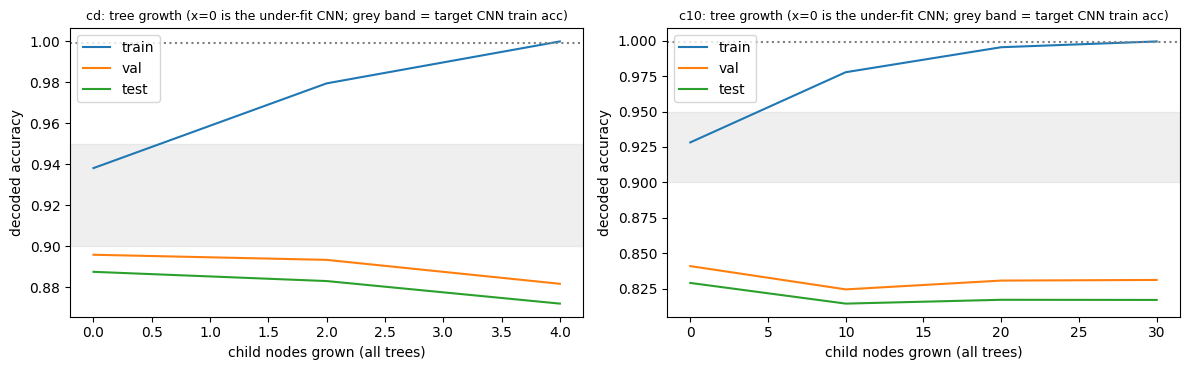

In [9]:
STEP(8, 'reporting the selected CNN+tree models: the tree itself drives train accuracy to ~100%')
def mcnemar_p(a, b):                                       # exact two-sided sign test on the discordant decisions (a = tree fixes, b = tree breaks)
    n = a + b; return 1.0 if n == 0 else min(1., 2*sum(math.comb(n, i) for i in range(min(a, b)+1))/2**n)
FINAL, FINAL_E = {}, {}
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for a_, ds in zip(ax, ['cd','c10']):
    D = DATA[ds]; E = GROWS[(ds,)+BEST[ds]]; r = E.snap; FINAL[ds], FINAL_E[ds] = r, E; b = cnn_acc(D); rf = cnn_acc(REFD[ds])
    print(f'===== {ds} | tree strategy {BEST[ds][0]} | node MLP widths {r["widths"]} | trunk {SEL[ds]} =====')
    print(f'reference conv.: train {100*rf["tr"]:.2f}%  val {100*rf["va"]:.2f}%  test {100*rf["te"]:.2f}%  | converged CNN ({REF_EP} ep), params {REFD[ds]["tparams"]}')
    print(f'under-fit CNN  : train {100*b["tr"]:.2f}%  val {100*b["va"]:.2f}%  test {100*b["te"]:.2f}%  | params {D["tparams"]}')
    print(f'CNN + tree     : train {100*r["train_acc"]:.2f}%  val {100*r["val_acc"]:.2f}%  test {100*r["test_acc"]:.2f}%  | tree nodes {r["nodes"]} (internal {r["internal"]}, leaves {r["leaves"]}) depth {r["tree_depth"]} | tree params {r["tree_params"]} | total {r["total_params"]}')
    print(f'Target {100*TARGET_TRAIN_ACC:.1f}% train: {"REACHED" if r["reached"] else "NOT reached (" + r["reason"] + ")"}   | train-test gap: CNN {100*(b["tr"]-b["te"]):.1f} pts -> CNN+tree {100*(r["train_acc"]-r["test_acc"]):.1f} pts')
    nt, nv = D['ntr'], D['nva']; Pc = D['logits'].argmax(1).numpy(); Pt = E.pred(E.Z())
    for nm, sl, yy in (('TRAIN', slice(0, nt), D['ytr']), ('TEST', slice(nt+nv, None), D['yte'])):
        okc, okt = Pc[sl] == yy, Pt[sl] == yy; fx, bk = int((~okc & okt).sum()), int((okc & ~okt).sum())
        print(f'   {nm:5s}: the tree fixes {fx} and breaks {bk} CNN decisions (net {fx-bk:+d}; sign-test p = {mcnemar_p(fx, bk):.3g})')
    S, W = tree_tables(E); S.to_csv(f'{OUT}/{ds}_tree_structure.csv', index=False); W.to_csv(f'{OUT}/{ds}_correction_weights.csv', index=False)
    print('views used by non-root nodes:', S[S.role!='root'].view.value_counts().to_dict())
    if len(W): print(f'alpha (A edges) mean {W[W.role=="A"].weight.mean():.2f} | beta (B edges) mean {W[W.role=="B"].weight.mean():.2f} | zero weights {int((W.weight==0).sum())}/{len(W)}')
    h = np.array(E.hist); a_.plot(h[:,0], h[:,1], label='train'); a_.plot(h[:,0], h[:,2], label='val'); a_.plot(h[:,0], h[:,3], label='test'); a_.axhline(TARGET_TRAIN_ACC, ls=':', c='gray'); a_.axhspan(*BAND, color='gray', alpha=.12)
    a_.set_xlabel('child nodes grown (all trees)'); a_.set_ylabel('decoded accuracy'); a_.set_title(f'{ds}: tree growth (x=0 is the under-fit CNN; grey band = target CNN train acc)', fontsize=9); a_.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/tree_growth.png', dpi=130); plt.show()

## STEP 9 — Double descent (model-size sweep, label noise)
Trunk width `w` (channels `w,2w,4w`) **and** node width are swept together; train labels have `NOISE` fraction flipped (test is clean); no augmentation / weight decay / lr decay so that the models can interpolate noisy labels; small data subset so interpolation happens at moderate width. We record the CNN head alone and the CNN+tree (fixed small node budget). Interpolation point = first width with noisy-train accuracy ≥ `INTERP`.

**v2:** dense widths 6–16 (where the interpolation threshold sits), **3 seeds**, longer training for cats-vs-dogs (`DD_EP['cd']`), and a lower tolerance: a peak counts if the mean test-error *rise* (before the peak) and *drop* (after it) both exceed `max(DD_TOL_MIN, largest standard error)`. The verdict also reports **per-seed support** — in how many individual seeds the same width is a local peak (rise > 0 and drop > 0). "SUPPORTED" needs ≥ 2/3 of the seeds; otherwise the verdict is downgraded to "suggestive".


▶ STEP 9/12: double-descent sweep over model width with noisy labels (trunk + tree), 3 seeds, dense widths around the interpolation threshold   [elapsed 21:23]
[cd] label noise 20%, widths [1, 2, 4, 6, 7, 8, 9, 10, 11, 12, 14, 16, 24, 32, 48], seeds [0, 1, 2], subset 3000, 120 epochs
    [cd] w= 1 seed=0 (21s): CNN train(noisy) 0.620 test 0.616 | +tree train 0.630 test 0.617
    [cd] w= 1 seed=1 (17s): CNN train(noisy) 0.626 test 0.567 | +tree train 0.635 test 0.557
    [cd] w= 1 seed=2 (17s): CNN train(noisy) 0.642 test 0.602 | +tree train 0.649 test 0.592
    [cd] w= 2 seed=0 (20s): CNN train(noisy) 0.681 test 0.558 | +tree train 0.784 test 0.572
    [cd] w= 2 seed=1 (18s): CNN train(noisy) 0.611 test 0.545 | +tree train 0.779 test 0.565
    [cd] w= 2 seed=2 (19s): CNN train(noisy) 0.737 test 0.562 | +tree train 0.786 test 0.553
    [cd] w= 4 seed=0 (19s): CNN train(noisy) 0.662 test 0.515 | +tree train 0.995 test 0.556
    [cd] w= 4 seed=1 (19s): CNN train(noisy) 0.585 test 0.525 |

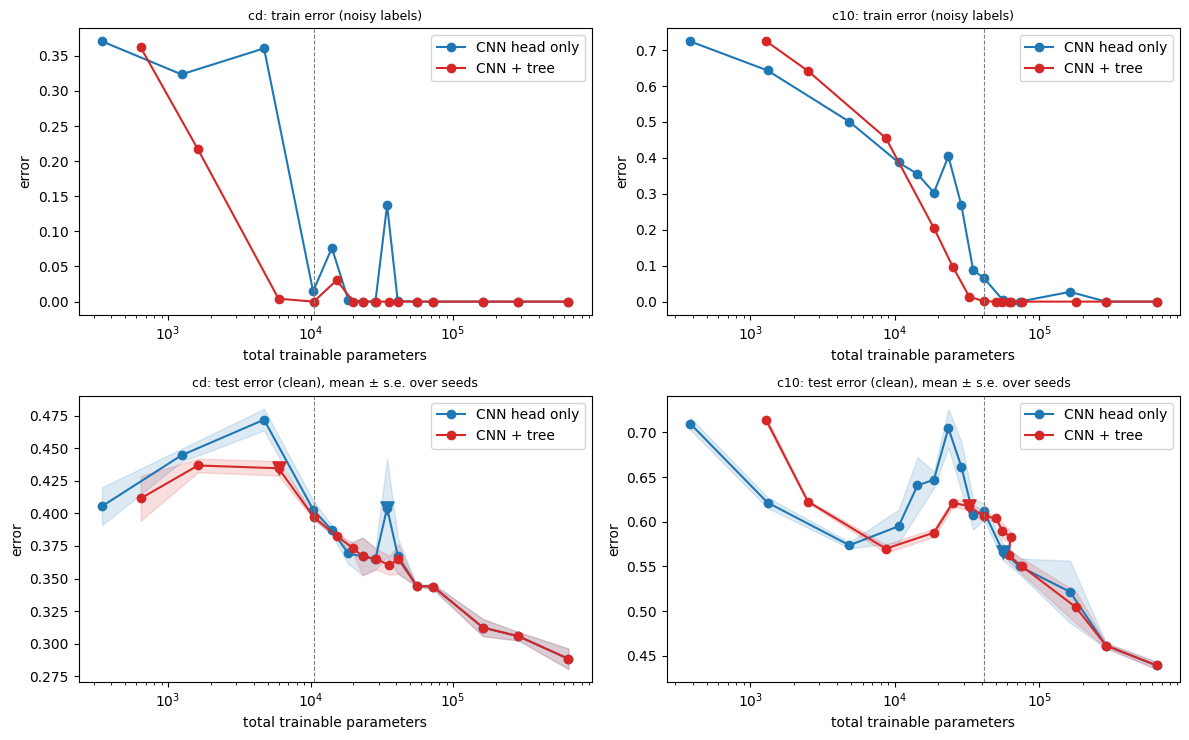

[None, None]

In [10]:
STEP(9, 'double-descent sweep over model width with noisy labels (trunk + tree), 3 seeds, dense widths around the interpolation threshold')
def dd_run(ds, w, seed):
    def f():
        I = IM[ds]; n = DD_N[ds]; nc = NC[ds]; yc = I['ytr'][:n]; yn = add_noise(yc, nc, NOISE, np.random.RandomState(1000+seed)); X = I['Xtr'][:n]; t0 = time.time()
        m = train_trunk(X, yn, nc, w, DD_EP[ds], 1e-3, 0., seed, aug=False, opt='adam'); D = make_D(m, (X, I['Xva'][:300], I['Xte'][:DD_TE]), (yc, I['yva'][:300], I['yte'][:DD_TE]), nc, NAMES[ds])
        c = cnn_acc(D, yn); E = TreeEnsemble(D, yn, get_layer_widths(2, max(2, w)), make_strategy('varied'), seed=seed, max_nodes=DD_NODES[ds]+1, max_ep=40); r = E.fit(None, DD_NODES[ds], CHECK[ds]); a = E.acc()
        print(f'    [{ds}] w={w:2d} seed={seed} ({time.time()-t0:.0f}s): CNN train(noisy) {c["tr"]:.3f} test {c["te"]:.3f} | +tree train {a["tr"]:.3f} test {a["te"]:.3f}')
        return dict(w=w, seed=seed, params_cnn=D['tparams'], params_tree=D['tparams']+r['tree_params'], cnn_tr=c['tr'], cnn_te=c['te'], tree_tr=a['tr'], tree_te=a['te'])
    return cached(f'dd2|{MODE}|{ds}|{w}|{seed}|{NOISE}|{DD_NODES[ds]}|{DD_EP[ds]}|{DD_N[ds]}', f)
def dd_verdict(df, g, k):                                  # returns (text, index of first interpolating width, info dict)
    trc, tec, sdc = f'{k}_tr', f'{k}_te', f'{k}_sd'; ws = g.index.values; err = 1 - g[tec].values; ns = df.seed.nunique(); ip = np.where(g[trc].values >= INTERP)[0]
    if not len(ip): return f'inconclusive: no width reached noisy-train acc >= {INTERP} (max {g[trc].max():.3f})', None, {}
    i0 = int(ip[0])
    if len(err) - i0 < 3: return 'inconclusive: fewer than 3 widths beyond interpolation', i0, {}
    pk = i0 - 1 + int(np.argmax(err[max(i0-1, 0):])); tol = max(DD_TOL_MIN, float(np.nanmax(g[sdc].values))/np.sqrt(ns))
    if pk >= len(err)-1 or pk == 0: return 'no convincing double descent (test-error peak at sweep edge)', i0, {}
    rise = float(err[pk]-err[:pk].min()); drop = float(err[pk]-err[pk+1:].min()); sup = 0
    for s_ in sorted(df.seed.unique()):
        e = 1 - df[df.seed==s_].set_index('w').loc[ws, tec].values; sup += int(e[pk]-e[:pk].min() > 0 and e[pk]-e[pk+1:].min() > 0)
    ok = rise > tol and drop > tol
    lab = ('SUPPORTED double descent' if sup >= math.ceil(2*ns/3) else 'suggestive of double descent (peak not consistent across seeds)') if ok else 'no convincing double descent'
    return f'{lab} (peak at w={ws[pk]}, rise {rise:.3f}, drop {drop:.3f}, tol {tol:.3f}, per-seed support {sup}/{ns}; heuristic)', i0, dict(pk=pk, rise=rise, drop=drop, tol=tol, support=sup, n_seeds=ns, ok=bool(ok))
DD, DDV, DDI, DDRAW = {}, {}, {}, {}; fig, ax = plt.subplots(2, 2, figsize=(12, 7.5))
for j, ds in enumerate(['cd','c10']):
    print(f'[{ds}] label noise {NOISE:.0%}, widths {DD_W}, seeds {DD_SEEDS}, subset {DD_N[ds]}, {DD_EP[ds]} epochs')
    df = pd.DataFrame([dd_run(ds, w, s) for w in DD_W for s in DD_SEEDS]); DDRAW[ds] = df; df.to_csv(f'{OUT}/{ds}_double_descent_raw.csv', index=False)
    g = df.groupby('w').agg(pc=('params_cnn','mean'), pt=('params_tree','mean'), cnn_tr=('cnn_tr','mean'), cnn_te=('cnn_te','mean'), cnn_sd=('cnn_te','std'), tree_tr=('tree_tr','mean'), tree_te=('tree_te','mean'), tree_sd=('tree_te','std')).sort_values('pc').fillna(0)
    g['cnn_se'] = g.cnn_sd/np.sqrt(len(DD_SEEDS)); g['tree_se'] = g.tree_sd/np.sqrt(len(DD_SEEDS)); DD[ds] = g; DDV[ds], DDI[ds] = {}, {}
    for k in ['cnn','tree']: DDV[ds][k], i0k, DDI[ds][k] = dd_verdict(df, g, k); DDI[ds][k]['i0'] = i0k
    i0 = DDI[ds]['tree']['i0']
    for r_, (what, lab) in enumerate([('tr','train error (noisy labels)'), ('te','test error (clean), mean ± s.e. over seeds')]):
        a_ = ax[r_, j]
        for k, pc, c in [('cnn','pc','C0'), ('tree','pt','C3')]:
            e = 1-g[f'{k}_{what}']; a_.plot(g[pc], e, 'o-', c=c, label='CNN head only' if k=='cnn' else 'CNN + tree')
            if what == 'te':
                a_.fill_between(g[pc], e-g[f'{k}_se'], e+g[f'{k}_se'], color=c, alpha=.15); pk_ = DDI[ds][k].get('pk')
                if pk_ is not None: a_.scatter([g[pc].iloc[pk_]], [e.iloc[pk_]], marker='v', s=90, c=c, zorder=5)
        a_.set_xscale('log'); a_.set_xlabel('total trainable parameters'); a_.set_ylabel('error'); a_.set_title(f'{ds}: {lab}', fontsize=9); a_.legend()
        if i0 is not None: a_.axvline(g.pt.iloc[i0], c='gray', ls='--', lw=.8)
    print(g.round(4).to_string()); print(f'  verdict [{ds}] CNN only: {DDV[ds]["cnn"]}\n  verdict [{ds}] CNN+tree: {DDV[ds]["tree"]}')
plt.tight_layout(); plt.savefig(f'{OUT}/double_descent.png', dpi=130); plt.show(); [DD[d].to_csv(f'{OUT}/{d}_double_descent.csv') for d in DD]

## STEP 10 — Receptive fields of tree nodes (occlusion sensitivity of each node's own score) + learned stem filters


▶ STEP 10/12: receptive-field visualisation: occlusion maps for root / depth-1 / deeper nodes, and first-layer filters   [elapsed 50:43]


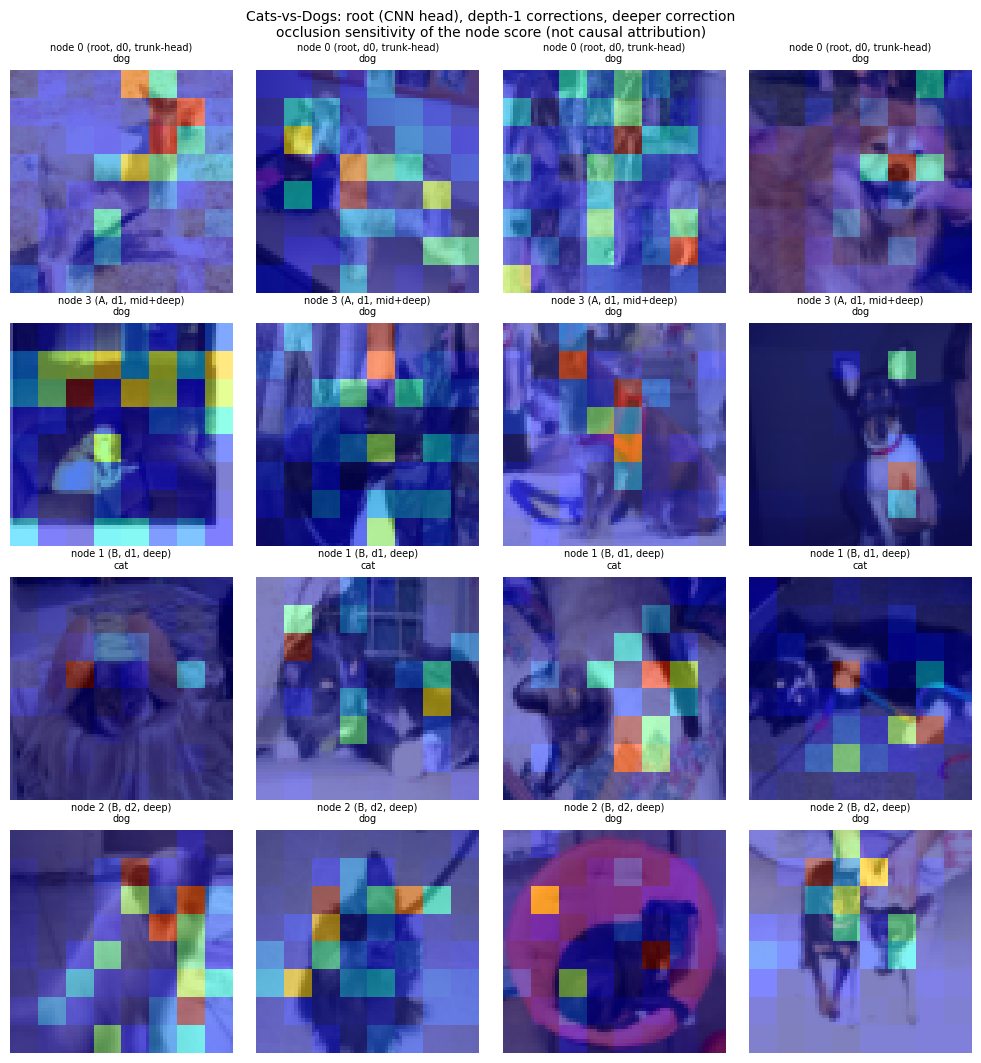

                            top10  center  corr_root
node role depth view                                
0    root 0     trunk-head  0.359   0.361        NaN
3    A    1     mid+deep    0.473   0.399      0.800
1    B    1     deep        0.548   0.408      0.676
2    B    2     deep        0.443   0.393      0.748
  (uniform baseline: top-10% cells mass 0.094, centre 4x4 mass 0.25)


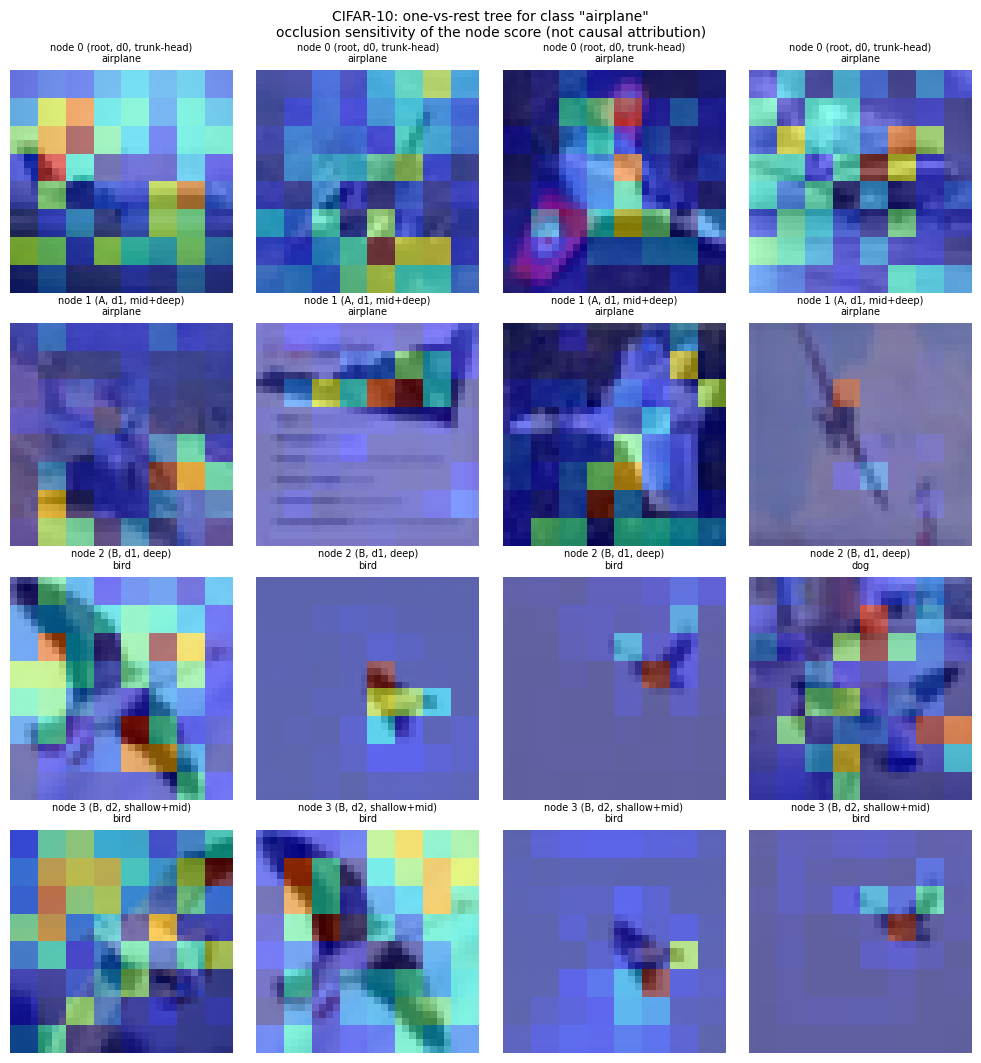

                             top10  center  corr_root
node role depth view                                 
0    root 0     trunk-head   0.280   0.320        NaN
1    A    1     mid+deep     0.513   0.470      0.446
2    B    1     deep         0.500   0.470      0.610
3    B    2     shallow+mid  0.393   0.355      0.453
  (uniform baseline: top-10% cells mass 0.094, centre 4x4 mass 0.25)


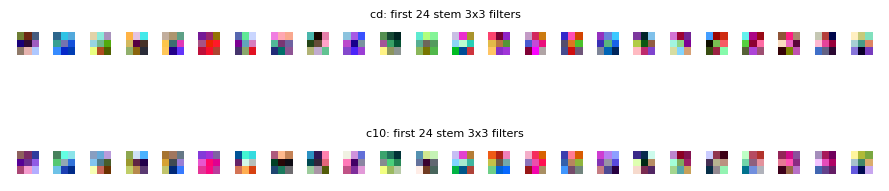

In [11]:
STEP(10, 'receptive-field visualisation: occlusion maps for root / depth-1 / deeper nodes, and first-layer filters')
def node_score(D, tree, nid, imgs_nhwc):
    lg, Fe = extract(D['trunk'], torch.from_numpy(np.ascontiguousarray(imgs_nhwc)).permute(0,3,1,2).contiguous()); nd = tree.nodes[nid]
    if nd['model'] is None: return root_scores(lg, D['nc'])[:,tree.k].numpy()
    with torch.no_grad(): return nd['model'](take(D, ((Fe-D['mu'])/D['sd']).clamp(-6,6), nd['view'])).squeeze(1).numpy()
def occl(D, tree, nid, img, g=8):
    H, W = img.shape[:2]; ys = np.linspace(0,H,g+1,dtype=int); xs = np.linspace(0,W,g+1,dtype=int); mean = img.reshape(-1,3).mean(0).astype(np.uint8); B = [img]
    for i in range(g):
        for j in range(g): o = img.copy(); o[ys[i]:ys[i+1], xs[j]:xs[j+1]] = mean; B.append(o)
    s = node_score(D, tree, nid, np.stack(B)); return np.abs(s[1:]-s[0]).reshape(g,g)
def rf_analysis(ds, tree, title):
    D, I = DATA[ds], IM[ds]; nodes = tree.nodes; sel = [0] + [nodes[0][r] for r in 'AB' if nodes[0][r] >= 0] + [n['id'] for n in nodes if n['depth'] >= 2][:1]; sel = sel[:4]; pos = 1 if D['nc']==2 else tree.k; rows = []
    fig, axes = plt.subplots(len(sel), 4, figsize=(10, 2.7*len(sel)), squeeze=False)
    for r, nid in enumerate(sel):
        nd = nodes[nid]
        if nid == 0: ids = np.where(I['yte']==pos)[0][:4]; imgs, labs = I['Xte'][ids], I['yte'][ids]                          # root: test images of the tree's class
        else: pool = nd['idx'][nd['t']==1][:4]; imgs, labs = I['Xtr'][pool], I['ytr'][pool]                                 # child: the hard samples it was built to fix
        for c, im in enumerate(imgs.permute(0,2,3,1).numpy()):
            m = occl(D, tree, nid, im); mr = occl(D, tree, 0, im) if nid else m; f = m/(m.sum()+1e-12)
            rows.append(dict(node=nid, role=nd['role'], depth=nd['depth'], view=nd['view'], top10=float(np.sort(f.ravel())[::-1][:6].sum()), center=float(f[2:6,2:6].sum()), corr_root=float(np.corrcoef(m.ravel(), mr.ravel())[0,1]) if nid and m.std()>0 and mr.std()>0 else np.nan))
            ax = axes[r,c]; ax.imshow(im); ax.imshow(cv2.resize(m.astype(np.float32), (im.shape[1],im.shape[0]), interpolation=cv2.INTER_NEAREST), cmap='jet', alpha=.5); ax.set_title(f'node {nid} ({nd["role"]}, d{nd["depth"]}, {nd["view"]})\n{D["names"][int(labs[c])]}', fontsize=7); ax.axis('off')
    plt.suptitle(title + '\nocclusion sensitivity of the node score (not causal attribution)', fontsize=10); plt.tight_layout(); plt.show()
    S = pd.DataFrame(rows).groupby(['node','role','depth','view'], sort=False)[['top10','center','corr_root']].mean(); print(S.round(3).to_string()); print('  (uniform baseline: top-10% cells mass 0.094, centre 4x4 mass 0.25)'); S.reset_index().to_csv(f'{OUT}/{ds}_rf_stats.csv', index=False); return S
RF = {}; RF['cd'] = rf_analysis('cd', FINAL_E['cd'].trees[0], 'Cats-vs-Dogs: root (CNN head), depth-1 corrections, deeper correction')
kb = int(np.argmax([len(t.nodes) for t in FINAL_E['c10'].trees])); RF['c10'] = rf_analysis('c10', FINAL_E['c10'].trees[kb], f'CIFAR-10: one-vs-rest tree for class "{C10_NAMES[kb]}"')
fig, axes = plt.subplots(2, 1, figsize=(9, 3.2))                                                                              # learned first-layer (stem) filters = lowest-level receptive fields
for a_, ds in zip(axes, ['cd','c10']):
    wt = DATA[ds]['trunk'].s1[0][0].weight.detach().cpu().float(); k = min(24, len(wt)); wt = (wt[:k]-wt[:k].amin((1,2,3),keepdim=True))/(wt[:k].amax((1,2,3),keepdim=True)-wt[:k].amin((1,2,3),keepdim=True)+1e-8)
    a_.imshow(torch.cat([f.permute(1,2,0) for f in torch.nn.functional.pad(wt, (1,1,1,1), value=1)], 1).numpy()); a_.axis('off'); a_.set_title(f'{ds}: first {k} stem 3x3 filters', fontsize=8)
plt.tight_layout(); plt.show()

### STEP 10b — Receptive-field observations  *(to be written after inspecting the plots above)*
> **TODO (author):** write the observations here once the occlusion maps and stem filters have been inspected. Quantities already printed in the table above that you can refer to: `top10` (mass in the 6 most sensitive cells; uniform baseline 0.094), `center` (mass in the central 4×4 cells; uniform baseline 0.25) and `corr_root` (correlation of a child's occlusion map with the root's map for the same image).

## STEP 11 — Minimising the network size
The question is *"what is the smallest model that is still good?"* — not just "the smallest one that reaches the target". Definitions (all on the **validation** split / **train** data; the test set plays no role in selection):
* **Candidates:** (a) **smaller roots** — narrower trunks, same recipe, small node MLPs; (b) **smaller nodes** — the whole node-MLP grid on the selected trunk; (c) **pruned trees** — every tree is also pruned post-hoc (`prune_ensemble`): subtrees are deleted from least to most important as long as decoded train accuracy does not drop below the target. The un-constrained pruning *path* of the selected model is also plotted.
* **Good** = reached the train-accuracy target **and** validation accuracy ≥ (best validation accuracy of any interpolating candidate) − 1 binomial standard error.
* **Smallest good model** = fewest total parameters (trunk + tree) among the good candidates. For context we also report the smallest *CNN alone* within one standard error of the best CNN-alone validation accuracy.
* Plots: validation and test accuracy vs. total parameters, with the validation Pareto frontier.


▶ STEP 11/12: size minimisation: accuracy-vs-parameters, smaller roots, smaller nodes, tree pruning -> smallest model within 1 standard error of the best validation accuracy   [elapsed 50:45]
[cd] (a) smaller roots: trunk widths [8, 12, 16, 24, 32, 48] (+ selected w=64); (b) node-size grid + (c) pruning on the selected trunk
    [cd] trunk w=8: CNN alone train 0.8553 val 0.8167 | +tree train 0.9922 val 0.7650 test 0.7825 | 91 nodes, 45024 params | all correction tasks resolved || pruned: 76 nodes, 40847 params, val 0.7650 (41s)
    [cd] trunk w=12: CNN alone train 0.8903 val 0.8717 | +tree train 0.9993 val 0.8383 test 0.8095 | 39 nodes, 57368 params | target reached || pruned: 37 nodes, 56370 params, val 0.8383 (21s)
    [cd] trunk w=16: CNN alone train 0.8978 val 0.8733 | +tree train 0.9991 val 0.8492 test 0.8405 | 29 nodes, 88818 params | target reached || pruned: 28 nodes, 88287 params, val 0.8492 (16s)
    [cd] trunk w=24: CNN alone train 0.9140 val 0.8717 | +tree train 0.9991 val

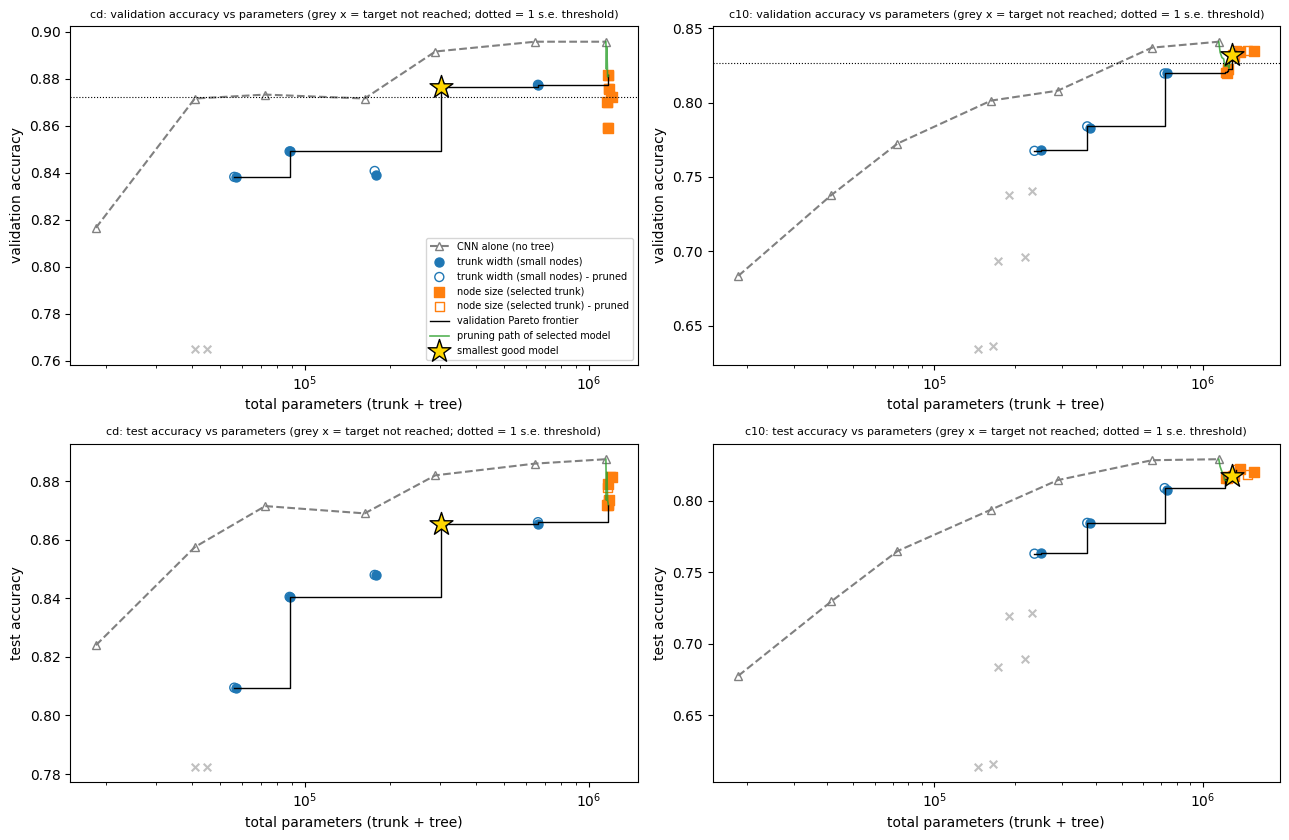

In [12]:
STEP(11, 'size minimisation: accuracy-vs-parameters, smaller roots, smaller nodes, tree pruning -> smallest model within 1 standard error of the best validation accuracy')
SZ_CFG = ('varied', 1, 8); slim = lambda s: {k: s[k] for k in ['train_acc','val_acc','test_acc','nodes','tree_params','total_params','reached']}
def size_run(ds, w):                                       # smaller root = narrower trunk (same epochs / lr / wd as the selected trunk) + small-node tree grown to the target, then pruned
    def f():
        s = SEL[ds]; t0 = time.time(); D = build_D(ds, load_or_train(ds, w, s['lr'], s['wd'], s['ep'])[0]); c = cnn_acc(D)
        r, E = run_tree(D, D['ytr'], SZ_CFG[0], SZ_CFG[1], SZ_CFG[2], TARGET_TRAIN_ACC, MAX_TOTAL[ds], MAX_NODES[ds], CHECK[ds]); pr = prune_ensemble(E, TARGET_TRAIN_ACC)
        print(f'    [{ds}] trunk w={w}: CNN alone train {c["tr"]:.4f} val {c["va"]:.4f} | +tree train {r["train_acc"]:.4f} val {r["val_acc"]:.4f} test {r["test_acc"]:.4f} | {r["nodes"]} nodes, {r["total_params"]} params | {r["reason"]} || pruned: {pr["pruned"]["nodes"]} nodes, {pr["pruned"]["total_params"]} params, val {pr["pruned"]["val_acc"]:.4f} ({time.time()-t0:.0f}s)')
        return dict(trunk_w=w, trunk_params=D['tparams'], cnn=c, full=slim(r), pruned=slim(pr['pruned']), reason=r['reason'])
    return cached(f'size2|{MODE}|{ds}|{w}|{SEL[ds]}|{TARGET_TRAIN_ACC}|{MAX_TOTAL[ds]}|{MAX_NODES[ds]}|{CHECK[ds]}', f)
CAND, PR, PATHS = [], {}, {}
def addrow(ds, family, label, w, s, pruned): CAND.append(dict(dataset=ds, family=family, model=label, trunk_w=w, pruned=pruned, total_params=int(s['total_params']), tree_params=int(s['tree_params']), nodes=int(s['nodes']), train=s['train_acc'], val=s['val_acc'], test=s['test_acc'], reached=bool(s['reached'])))
for ds in ['cd','c10']:
    sel = SEL[ds]; widths = [w for w in SIZE_W if w < sel['w']]; print(f'[{ds}] (a) smaller roots: trunk widths {widths} (+ selected w={sel["w"]}); (b) node-size grid + (c) pruning on the selected trunk')
    for w in widths:
        r = size_run(ds, w); c = r['cnn']
        CAND.append(dict(dataset=ds, family='CNN only', model=f'CNN alone w={w}', trunk_w=w, pruned=False, total_params=r['trunk_params'], tree_params=0, nodes=0, train=c['tr'], val=c['va'], test=c['te'], reached=False))
        addrow(ds, 'trunk width (small nodes)', f'w={w} {SZ_CFG}', w, r['full'], False); addrow(ds, 'trunk width (small nodes)', f'w={w} {SZ_CFG} pruned', w, r['pruned'], True)
    c = cnn_acc(DATA[ds]); CAND.append(dict(dataset=ds, family='CNN only', model=f'CNN alone w={sel["w"]} (selected)', trunk_w=sel['w'], pruned=False, total_params=DATA[ds]['tparams'], tree_params=0, nodes=0, train=c['tr'], val=c['va'], test=c['te'], reached=False))
    for (st, L, nw) in TREE_GRID:
        t0 = time.time(); E = GROWS[(ds, st, L, nw)]; PR[(ds, st, L, nw)] = pr = prune_ensemble(E, TARGET_TRAIN_ACC)
        addrow(ds, 'node size (selected trunk)', f'w={sel["w"]} nodes {st},L={L},w={nw}', sel['w'], E.snap, False); addrow(ds, 'node size (selected trunk)', f'w={sel["w"]} nodes {st},L={L},w={nw} pruned', sel['w'], pr['pruned'], True)
        print(f'    [{ds}] nodes {st},L={L},w={nw}: {E.snap["nodes"]} nodes / {E.snap["total_params"]} params -> pruned {pr["pruned"]["nodes"]} nodes / {pr["pruned"]["total_params"]} params | train {pr["pruned"]["train_acc"]:.4f} val {pr["pruned"]["val_acc"]:.4f} ({time.time()-t0:.0f}s)')
    PATHS[ds] = PR[(ds,)+BEST[ds]]['path']
CD = pd.DataFrame(CAND); CD['good'] = False; MIN, CNNMIN, THR = {}, {}, {}
for ds in ['cd','c10']:
    d = CD[CD.dataset==ds]; tm = d[(d.family != 'CNN only') & d.reached]; nva = DATA[ds]['nva']
    if not len(tm): print(f'[{ds}] no tree model reached the {TARGET_TRAIN_ACC} train target'); continue
    vb = tm.val.max(); se = math.sqrt(vb*(1-vb)/nva); THR[ds] = vb - VAL_SE_K*se; good = tm[tm.val >= THR[ds]].sort_values(['total_params','val'], ascending=[True,False]); CD.loc[good.index, 'good'] = True; MIN[ds] = good.iloc[0]
    co = d[d.family=='CNN only']; cb = co.val.max(); cse = math.sqrt(cb*(1-cb)/nva); CNNMIN[ds] = co[co.val >= cb - cse].sort_values('total_params').iloc[0]
    print(f'\n===== {ds} size minimisation (total = trunk + tree parameters; good = reached target AND val >= {THR[ds]:.4f} = best {vb:.4f} - {VAL_SE_K:g} s.e. {se:.4f}) =====')
    print(CD[CD.dataset==ds].sort_values('total_params').drop(columns=['dataset','trunk_w']).round(4).to_string(index=False))
    m = MIN[ds]; print(f'-> SMALLEST GOOD MODEL [{ds}]: "{m.model}" | {int(m.total_params)} params ({int(m.total_params-m.tree_params)} trunk + {int(m.tree_params)} tree, {int(m.nodes)} tree nodes) | train {m.train:.4f} val {m.val:.4f} test {m.test:.4f}')
    print(f'   vs selected main model: {FINAL[ds]["total_params"]} params ({FINAL[ds]["total_params"]/m.total_params:.1f}x larger) | smallest CNN alone within 1 s.e. of its best val: {int(CNNMIN[ds].total_params)} params (val {CNNMIN[ds].val:.4f}, train {CNNMIN[ds].train:.4f}, test {CNNMIN[ds].test:.4f})')
CD.to_csv(f'{OUT}/size_minimisation.csv', index=False)
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for j, ds in enumerate(['cd','c10']):
    d = CD[CD.dataset==ds]; tm = d[(d.family != 'CNN only') & d.reached].sort_values('total_params'); fr = tm[tm.val.cummax() == tm.val]; fr = fr[fr.val > fr.val.shift(1, fill_value=-1)]
    for r_, (col, ttl) in enumerate([('val','validation accuracy'), ('test','test accuracy')]):
        a_ = axes[r_, j]; co = d[d.family=='CNN only'].sort_values('total_params'); a_.plot(co.total_params, co[col], '^--', c='gray', mfc='none', label='CNN alone (no tree)')
        for fam, c, mk in [('trunk width (small nodes)','C0','o'), ('node size (selected trunk)','C1','s')]:
            for pr_ in (False, True):
                q = d[(d.family==fam) & (d.pruned==pr_)]; ok_, no_ = q[q.reached], q[~q.reached]
                a_.scatter(ok_.total_params, ok_[col], marker=mk, facecolors='none' if pr_ else c, edgecolors=c, s=42, label=f'{fam}{" - pruned" if pr_ else ""}')
                if len(no_): a_.scatter(no_.total_params, no_[col], marker='x', c='silver', s=30)
        a_.step(fr.total_params, fr[col], where='post', c='k', lw=1, label='validation Pareto frontier'); pp = pd.DataFrame(PATHS[ds]); a_.plot(pp.total_params, pp['val_acc' if col=='val' else 'test_acc'], '-', c='C2', lw=1.2, alpha=.8, label='pruning path of selected model')
        if ds in MIN: a_.scatter([MIN[ds].total_params], [MIN[ds][col]], marker='*', s=300, c='gold', edgecolors='k', zorder=6, label='smallest good model')
        if col == 'val' and ds in THR: a_.axhline(THR[ds], ls=':', c='k', lw=.8)
        a_.set_xscale('log'); a_.set_xlabel('total parameters (trunk + tree)'); a_.set_ylabel(ttl); a_.set_title(f'{ds}: {ttl} vs parameters (grey x = target not reached; dotted = 1 s.e. threshold)', fontsize=8)
        if r_ == 0 and j == 0: a_.legend(fontsize=7, loc='lower right')
plt.tight_layout(); plt.savefig(f'{OUT}/size_vs_accuracy.png', dpi=130); plt.show()

## STEP 12 — Final comparison and measured-facts summary

In [13]:
STEP(12, 'final tables, automatically generated summary and evidence checklist (only measured numbers)')
rows = []
for ds in ['cd','c10']:
    rf, b, f = cnn_acc(REFD[ds]), cnn_acc(DATA[ds]), FINAL[ds]; pm = PR[(ds,)+BEST[ds]]['pruned']; s = SEL[ds]
    rows.append(dict(dataset=ds, model=f'reference: converged CNN ({REF_EP} ep)', train=rf['tr'], val=rf['va'], test=rf['te'], params=REFD[ds]['tparams'], tree_nodes=0))
    rows.append(dict(dataset=ds, model=f'under-fit CNN alone ({s["ep"]} ep, w={s["w"]})', train=b['tr'], val=b['va'], test=b['te'], params=DATA[ds]['tparams'], tree_nodes=0))
    rows.append(dict(dataset=ds, model=f'under-fit CNN + tree {BEST[ds]}', train=f['train_acc'], val=f['val_acc'], test=f['test_acc'], params=f['total_params'], tree_nodes=f['nodes']))
    rows.append(dict(dataset=ds, model=f'  ... same tree, pruned', train=pm['train_acc'], val=pm['val_acc'], test=pm['test_acc'], params=pm['total_params'], tree_nodes=pm['nodes']))
    if ds in MIN: m = MIN[ds]; rows.append(dict(dataset=ds, model=f'smallest good model: {m.model}', train=m.train, val=m.val, test=m.test, params=int(m.total_params), tree_nodes=int(m.nodes)))
FT = pd.DataFrame(rows); print(FT.round(4).to_string(index=False)); FT.to_csv(f'{OUT}/final_comparison.csv', index=False); print()
for ds in ['cd','c10']:
    f = FINAL[ds]; b = cnn_acc(DATA[ds]); R = RF[ds]
    print(f'[{ds}] under-fit CNN -> + tree: train {100*b["tr"]:.2f}% -> {100*f["train_acc"]:.2f}% ({"target reached" if f["reached"] else "target NOT reached: " + f["reason"]}), val {100*b["va"]:.2f}% -> {100*f["val_acc"]:.2f}%, test {100*b["te"]:.2f}% -> {100*f["test_acc"]:.2f}% ({f["nodes"]} nodes).')
    print(f'   generalisation gap (train-test): {100*(b["tr"]-b["te"]):.1f} pts (CNN) -> {100*(f["train_acc"]-f["test_acc"]):.1f} pts (CNN+tree); the extra train accuracy is memorisation by the tree, not a test gain unless the sign tests in STEP 8 say so.')
    print(f'   double descent: CNN only -> {DDV[ds]["cnn"]}\n                   CNN+tree -> {DDV[ds]["tree"]}')
    print(f'   occlusion: mean top-10%-cell mass {R.top10.mean():.2f} (uniform 0.09), mean centre mass {R.center.mean():.2f} (uniform 0.25); child-vs-root map correlation {R.corr_root.dropna().mean():.2f}.')
    if ds in MIN: print(f'   smallest good model: {int(MIN[ds].total_params)} params ("{MIN[ds].model}") vs selected {f["total_params"]} params.')
print('\nEVIDENCE CHECKLIST (each line is computed from the measured numbers above; nothing is hard-coded)')
for ds in ['cd','c10']:
    f = FINAL[ds]; b = cnn_acc(DATA[ds]); dv = DDV[ds]['tree']
    chk = [(f'CNN trunk train acc inside {BAND}', BAND[0] <= b['tr'] <= BAND[1], f'{100*b["tr"]:.1f}%'),
           (f'tree itself lifts train acc to >= {100*TARGET_TRAIN_ACC:.1f}%', bool(f['reached']), f'{100*b["tr"]:.1f}% -> {100*f["train_acc"]:.2f}% with {f["nodes"]} nodes'),
           ('double descent supported across seeds (CNN+tree)', 'SUPPORTED' in dv, dv.split(' (')[0]),
           ('smallest good model identified (within 1 s.e. of best val, interpolating)', ds in MIN, f'{int(MIN[ds].total_params)} params' if ds in MIN else 'none')]
    for name, ok, det in chk: print(f'  [{"PASS" if ok else "FAIL"}] {ds}: {name}  ({det})')
print('\nCaveats: DD uses 3 seeds and a heuristic verdict; occlusion maps show input sensitivity, not causality; the tree is fit to the training set by design, so a train/test gap is expected; validation-based selection uses a finite validation set (see the s.e. rule).')
print(f'Total run time: {(time.time()-T0)/60:.1f} min. All tables/plots data saved under {OUT}')


▶ STEP 12/12: final tables, automatically generated summary and evidence checklist (only measured numbers)   [elapsed 66:54]
dataset                                                  model  train    val   test  params  tree_nodes
     cd                       reference: converged CNN (30 ep) 0.9793 0.9075 0.9055 1146818           0
     cd                      under-fit CNN alone (16 ep, w=64) 0.9381 0.8958 0.8875 1146818           0
     cd                 under-fit CNN + tree ('varied', 2, 16) 0.9999 0.8817 0.8720 1169676           5
     cd                                  ... same tree, pruned 0.9999 0.8817 0.8720 1169676           5
     cd      smallest good model: w=32 ('varied', 1, 8) pruned 0.9991 0.8767 0.8655  302285          14
    c10                       reference: converged CNN (30 ep) 0.9900 0.8458 0.8504 1148874           0
    c10                      under-fit CNN alone (16 ep, w=64) 0.9282 0.8409 0.8290 1148874           0
    c10                 under-fit CNN + tr